# Multiplayer Top Trumps: Setup & Exploration

## Erweiterung auf 3+ Spieler mit konfigurierbaren Strategien

Dieses Notebook erweitert die ursprüngliche 2-Spieler-Analyse auf **Multiplayer-Szenarien**.

### Konfigurierbare Spieler-Strategien

| Strategie | Beschreibung |
|-----------|-------------|
| `p0` | **Anfänger:** Wählt Kategorie mit höchstem normalisierten Wert |
| `p4` | **Experte:** Berechnet Gewinnwahrscheinlichkeit gegen verbleibende Karten |

### Beispiel-Konfigurationen

- `['p4', 'p0']` - Standard 2-Spieler (1 Experte, 1 Anfänger)
- `['p4', 'p0', 'p0']` - 3 Spieler (1 Experte, 2 Anfänger)
- `['p4', 'p4', 'p0']` - 3 Spieler (2 Experten, 1 Anfänger)
- `['p4', 'p0', 'p0', 'p0']` - 4 Spieler (1 Experte, 3 Anfänger)

## 1. Setup

In [1]:
%pip install numpy pymoo pandas matplotlib seaborn --quiet


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path
sys.path.insert(0, str(Path('.').resolve().parent))
import json

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['font.size'] = 20
plt.rcParams['axes.titlesize'] = 26
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['legend.fontsize'] = 16

In [3]:
from simulation import (
    TopTrumpsMultiplayerSimulation,
    TopTrumpsMultiplayerBalancing,
    evaluate_multiplayer_deck_detailed
)

print('Multiplayer simulation loaded successfully!')

Multiplayer simulation loaded successfully!


In [4]:
SEED = 42

def set_seeds(seed):
    np.random.seed(seed)
    random.seed(seed)

set_seeds(SEED)

In [5]:
RESULTS_DIR = Path('../results/multiplayer')
PLOTS_DIR = Path('../plots/multiplayer')

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Multiplayer Results: {RESULTS_DIR.absolute()}')
print(f'Multiplayer Plots: {PLOTS_DIR.absolute()}')

Multiplayer Results: /Users/tim.strauss/ODM/odm_sheet1/case-study/TimsExperiments/results/multiplayer
Multiplayer Plots: /Users/tim.strauss/ODM/odm_sheet1/case-study/TimsExperiments/plots/multiplayer


---

## 2. Spieler-Konfiguration

Hier kannst du die Anzahl und Strategien der Spieler einstellen.

In [6]:
# ============================================================
# KONFIGURATION: Passe diese Parameter an!
# ============================================================

# Anzahl Karten (muss durch Anzahl Spieler teilbar sein!)
K = 24  # 24 Karten für 3 oder 4 Spieler gut geeignet

# Anzahl Kategorien
L = 4

# Wertebereich
XL = 1.0
XU = 10.0

# Spieler-Strategien: Liste von 'p0' (Anfänger) oder 'p4' (Experte)
PLAYER_STRATEGIES = ['p4', 'p0', 'p0']  # 3 Spieler: 1 Experte, 2 Anfänger

# Simulations per deck
R_EVAL_FAST = 1000   # During optimization
R_EVAL_FINAL = 1500  # For validation

# ============================================================

NUM_PLAYERS = len(PLAYER_STRATEGIES)
NUM_EXPERTS = PLAYER_STRATEGIES.count('p4')
NUM_BEGINNERS = PLAYER_STRATEGIES.count('p0')

assert K % NUM_PLAYERS == 0, f'K={K} muss durch NUM_PLAYERS={NUM_PLAYERS} teilbar sein!'

CARDS_PER_PLAYER = K // NUM_PLAYERS

print('=' * 50)
print('MULTIPLAYER KONFIGURATION')
print('=' * 50)
print(f'Anzahl Spieler:     {NUM_PLAYERS}')
print(f'Strategien:         {PLAYER_STRATEGIES}')
print(f'  - Experten (p4):  {NUM_EXPERTS}')
print(f'  - Anfänger (p0):  {NUM_BEGINNERS}')
print(f'Karten im Deck:     {K}')
print(f'Karten pro Spieler: {CARDS_PER_PLAYER}')
print(f'Kategorien:         {L}')
print(f'Wertebereich:       [{XL}, {XU}]')
print(f'R_fast:             {R_EVAL_FAST}')
print(f'R_final:            {R_EVAL_FINAL}')
print('=' * 50)

MULTIPLAYER KONFIGURATION
Anzahl Spieler:     3
Strategien:         ['p4', 'p0', 'p0']
  - Experten (p4):  1
  - Anfänger (p0):  2
Karten im Deck:     24
Karten pro Spieler: 8
Kategorien:         4
Wertebereich:       [1.0, 10.0]
R_fast:             1000
R_final:            1500


In [7]:
CONFIG = {
    'seed': SEED,
    'K': K,
    'L': L,
    'n_var': K * L,
    'xl': XL,
    'xu': XU,
    'player_strategies': PLAYER_STRATEGIES,
    'num_players': NUM_PLAYERS,
    'num_experts': NUM_EXPERTS,
    'num_beginners': NUM_BEGINNERS,
    'cards_per_player': CARDS_PER_PLAYER,
    'R_eval_fast': R_EVAL_FAST,
    'R_eval_final': R_EVAL_FINAL
}

config_path = RESULTS_DIR / 'config.json'
with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print(f'Konfiguration gespeichert: {config_path}')

Konfiguration gespeichert: results/multiplayer/config.json


---

## 3. Simulation erstellen & testen

In [8]:
sim = TopTrumpsMultiplayerSimulation(
    num_cards=K,
    num_categories=L,
    player_strategies=PLAYER_STRATEGIES
)

print(f'Multiplayer Simulation erstellt:')
print(f'  - {sim.num_players} Spieler')
print(f'  - {sim.K} Karten')
print(f'  - {sim.L} Kategorien')
print(f'  - {sim.cards_per_player} Karten pro Spieler')

Multiplayer Simulation erstellt:
  - 3 Spieler
  - 24 Karten
  - 4 Kategorien
  - 8 Karten pro Spieler


In [9]:
# Einzelnes Testspiel
set_seeds(SEED)
sim.set_random_deck()

result = sim.simulate_game()

print('\n=== Testspiel Ergebnis ===')
print(f'Tricks gewonnen: {result["tricks_won"]}')
for i, tricks in enumerate(result['tricks_won']):
    strategy = PLAYER_STRATEGIES[i]
    print(f'  Spieler {i} ({strategy}): {tricks} Tricks')
print(f'Gewinner: Spieler {result["winner_idx"]} ({PLAYER_STRATEGIES[result["winner_idx"]]})')
print(f'Führungswechsel: {result["trick_changes"]}')
print(f'Unentschieden: {result["is_tie"]}')


=== Testspiel Ergebnis ===
Tricks gewonnen: [0, 3, 5]
  Spieler 0 (p4): 0 Tricks
  Spieler 1 (p0): 3 Tricks
  Spieler 2 (p0): 5 Tricks
Gewinner: Spieler 2 (p0)
Führungswechsel: 2
Unentschieden: False


---

## 4. Sanity Checks

In [10]:
set_seeds(SEED)

test_decks = [
    ('Random Deck 1', np.random.uniform(XL, XU, K * L)),
    ('Random Deck 2', np.random.uniform(XL, XU, K * L)),
    ('Uniform Low Variance', np.random.uniform(4.5, 5.5, K * L)),
    ('High Variance', np.random.uniform(1, 10, K * L))
]

results_list = []
for name, deck in test_decks:
    metrics = evaluate_multiplayer_deck_detailed(sim, deck, R=R_EVAL_FAST)
    results_list.append({
        'Deck': name,
        'Focus E WR': f'{metrics["focus_expert_win_rate"]:.1%}',
        'Any E WR': f'{metrics["any_expert_win_rate"]:.1%}',
        'Trick Changes': f'{metrics["trick_changes"]:.2f}',
        'Tie Rate': f'{metrics["tie_rate"]:.1%}',
        'Tricks P0': f'{metrics["tricks_per_player_mean"][0]:.2f}',
        'Tricks P1': f'{metrics["tricks_per_player_mean"][1]:.2f}' if NUM_PLAYERS > 1 else '-',
        'Tricks P2': f'{metrics["tricks_per_player_mean"][2]:.2f}' if NUM_PLAYERS > 2 else '-'
    })

results_table = pd.DataFrame(results_list)
print(f'\n=== Sanity Check: {NUM_PLAYERS} Players, Strategies {PLAYER_STRATEGIES} (R={R_EVAL_FAST}) ===')
print(results_table.to_string(index=False))


=== Sanity Check: 3 Players, Strategies ['p4', 'p0', 'p0'] (R=1000) ===
                Deck Focus E WR Any E WR Trick Changes Tie Rate Tricks P0 Tricks P1 Tricks P2
       Random Deck 1      42.0%    42.0%          2.46    13.6%      2.82      2.52      2.66
       Random Deck 2      39.8%    39.8%          2.56    14.4%      2.79      2.58      2.63
Uniform Low Variance      45.4%    45.4%          2.57    15.6%      2.97      2.49      2.54
       High Variance      44.6%    44.6%          2.93    16.1%      2.89      2.49      2.62


### 4.1 Noisiness-Test

In [11]:
set_seeds(SEED)
fixed_deck = np.random.uniform(XL, XU, K * L)

noise_results = []
for run in range(10):
    metrics = evaluate_multiplayer_deck_detailed(sim, fixed_deck, R=200)
    noise_results.append({
        'Run': run + 1,
        'Focus Expert Win Rate': metrics['focus_expert_win_rate'],
        'Trick Changes': metrics['trick_changes']
    })

noise_df = pd.DataFrame(noise_results)

print(f'\n=== Noisiness Test: Same Deck, 10 Evaluations (R=200) ===')
print(f'Focus Expert Win Rate - Mean: {noise_df["Focus Expert Win Rate"].mean():.1%}, Std: {noise_df["Focus Expert Win Rate"].std():.3f}')
print(f'Trick Changes         - Mean: {noise_df["Trick Changes"].mean():.2f}, Std: {noise_df["Trick Changes"].std():.3f}')


=== Noisiness Test: Same Deck, 10 Evaluations (R=200) ===
Focus Expert Win Rate - Mean: 40.5%, Std: 0.037
Trick Changes         - Mean: 2.42, Std: 0.077


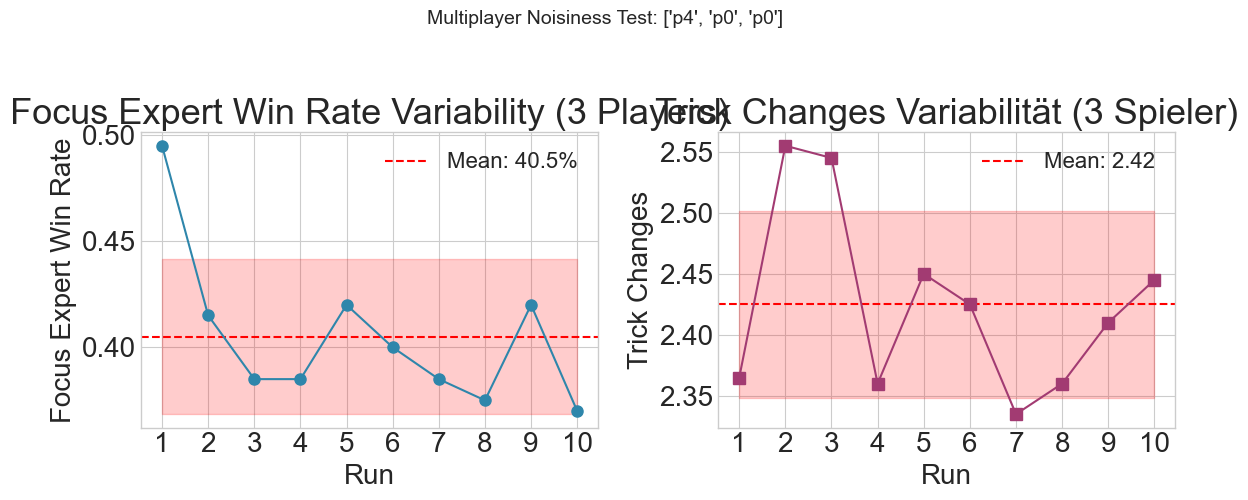


-> Plot gespeichert: plots/multiplayer/noisiness_test.png


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax1 = axes[0]
ax1.errorbar(range(1, 11), noise_df['Focus Expert Win Rate'], fmt='o-', capsize=5, markersize=8, color='#2E86AB')
ax1.axhline(noise_df['Focus Expert Win Rate'].mean(), color='red', linestyle='--', label=f'Mean: {noise_df["Focus Expert Win Rate"].mean():.1%}')
ax1.fill_between(range(1, 11),
                 noise_df['Focus Expert Win Rate'].mean() - noise_df['Focus Expert Win Rate'].std(),
                 noise_df['Focus Expert Win Rate'].mean() + noise_df['Focus Expert Win Rate'].std(),
                 alpha=0.2, color='red')
ax1.set_xlabel('Run')
ax1.set_ylabel('Focus Expert Win Rate')
ax1.set_title(f'Focus Expert Win Rate Variability ({NUM_PLAYERS} Players)')
ax1.legend()
ax1.set_xticks(range(1, 11))

ax2 = axes[1]
ax2.errorbar(range(1, 11), noise_df['Trick Changes'], fmt='s-', capsize=5, markersize=8, color='#A23B72')
ax2.axhline(noise_df['Trick Changes'].mean(), color='red', linestyle='--', label=f'Mean: {noise_df["Trick Changes"].mean():.2f}')
ax2.fill_between(range(1, 11),
                 noise_df['Trick Changes'].mean() - noise_df['Trick Changes'].std(),
                 noise_df['Trick Changes'].mean() + noise_df['Trick Changes'].std(),
                 alpha=0.2, color='red')
ax2.set_xlabel('Run')
ax2.set_ylabel('Trick Changes')
ax2.set_title(f'Trick Changes Variabilität ({NUM_PLAYERS} Spieler)')
ax2.legend()
ax2.set_xticks(range(1, 11))

plt.suptitle(f'Multiplayer Noisiness Test: {PLAYER_STRATEGIES}', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'noisiness_test.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n-> Plot gespeichert: {PLOTS_DIR / "noisiness_test.png"}')

---

## 5. Objective Space Exploration

In [13]:
set_seeds(SEED)

n_random_samples = 100
exploration_results = []

print(f'Generiere {n_random_samples} zufällige Decks für {NUM_PLAYERS} Spieler...')
for i in range(n_random_samples):
    deck = np.random.uniform(XL, XU, K * L)
    metrics = evaluate_multiplayer_deck_detailed(sim, deck, R=100)
    exploration_results.append({
        'focus_expert_win_rate': metrics['focus_expert_win_rate'],
        'trick_changes': metrics['trick_changes'],
        'tie_rate': metrics['tie_rate']
    })
    if (i + 1) % 20 == 0:
        print(f'  {i + 1}/{n_random_samples} fertig')

exploration_df = pd.DataFrame(exploration_results)
print('Done!')

Generiere 100 zufällige Decks für 3 Spieler...
  20/100 fertig
  40/100 fertig
  60/100 fertig
  80/100 fertig
  100/100 fertig
Done!


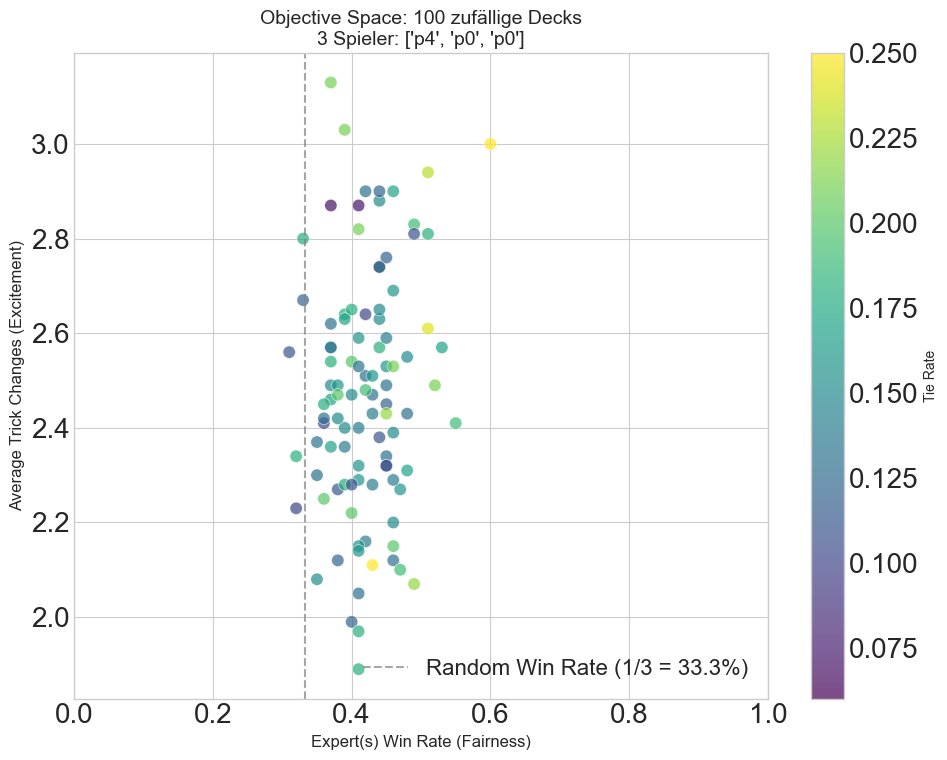


-> Plot gespeichert: plots/multiplayer/objective_space_exploration.png


In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

scatter = ax.scatter(
    exploration_df['focus_expert_win_rate'],
    exploration_df['trick_changes'],
    c=exploration_df['tie_rate'],
    cmap='viridis',
    s=80,
    alpha=0.7,
    edgecolors='white',
    linewidth=0.5
)

expected_random_win = 1 / NUM_PLAYERS
ax.axvline(expected_random_win, color='gray', linestyle='--', alpha=0.7, 
           label=f'Random Win Rate (1/{NUM_PLAYERS} = {expected_random_win:.1%})')

ax.set_xlabel('Expert(s) Win Rate (Fairness)', fontsize=12)
ax.set_ylabel('Average Trick Changes (Excitement)', fontsize=12)
ax.set_title(f'Objective Space: {n_random_samples} zufällige Decks\n'
             f'{NUM_PLAYERS} Spieler: {PLAYER_STRATEGIES}', fontsize=14)

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Tie Rate', fontsize=10)

ax.set_xlim(0, 1)
ax.legend(loc='lower right')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'objective_space_exploration.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n-> Plot gespeichert: {PLOTS_DIR / "objective_space_exploration.png"}')

In [15]:
print(f'\n=== Statistical Summary of Exploration ({NUM_PLAYERS} Players) ===')
print(f'Focus Expert Win Rate: Min={exploration_df["focus_expert_win_rate"].min():.1%}, Max={exploration_df["focus_expert_win_rate"].max():.1%}, Mean={exploration_df["focus_expert_win_rate"].mean():.1%}')
print(f'Trick Changes:   Min={exploration_df["trick_changes"].min():.2f}, Max={exploration_df["trick_changes"].max():.2f}, Mean={exploration_df["trick_changes"].mean():.2f}')
print(f'Tie Rate:        Min={exploration_df["tie_rate"].min():.1%}, Max={exploration_df["tie_rate"].max():.1%}, Mean={exploration_df["tie_rate"].mean():.1%}')

CONFIG['exploration_stats'] = {
    'focus_expert_win_rate_range': [float(exploration_df['focus_expert_win_rate'].min()), float(exploration_df['focus_expert_win_rate'].max())],
    'trick_changes_range': [float(exploration_df['trick_changes'].min()), float(exploration_df['trick_changes'].max())],
    'tie_rate_range': [float(exploration_df['tie_rate'].min()), float(exploration_df['tie_rate'].max())]
}

with open(config_path, 'w') as f:
    json.dump(CONFIG, f, indent=2)

print(f'\nKonfiguration aktualisiert: {config_path}')


=== Statistical Summary of Exploration (3 Players) ===
Focus Expert Win Rate: Min=31.0%, Max=60.0%, Mean=42.1%
Trick Changes:   Min=1.89, Max=3.13, Mean=2.47
Tie Rate:        Min=6.0%, Max=25.0%, Mean=15.6%

Konfiguration aktualisiert: results/multiplayer/config.json


---

## 6. Vergleich: Verschiedene Spieler-Konfigurationen

In [16]:
CONFIGURATIONS = [
    {'K': 22, 'strategies': ['p4', 'p0'], 'label': '2P: 1E/1B'},
    {'K': 24, 'strategies': ['p4', 'p0', 'p0'], 'label': '3P: 1E/2B'},
    {'K': 24, 'strategies': ['p4', 'p4', 'p0'], 'label': '3P: 2E/1B'},
    {'K': 24, 'strategies': ['p4', 'p0', 'p0', 'p0'], 'label': '4P: 1E/3B'},
]

comparison_results = []

set_seeds(SEED)
test_deck_base = np.random.uniform(XL, XU, 96)

print('Vergleiche verschiedene Spieler-Konfigurationen...\n')

for config in CONFIGURATIONS:
    k = config['K']
    strategies = config['strategies']
    label = config['label']
    
    test_sim = TopTrumpsMultiplayerSimulation(
        num_cards=k,
        num_categories=L,
        player_strategies=strategies
    )
    
    deck = test_deck_base[:k * L]
    metrics = evaluate_multiplayer_deck_detailed(test_sim, deck, R=500)
    
    comparison_results.append({
        'Config': label,
        'Players': len(strategies),
        'Focus Expert Win Rate': metrics['focus_expert_win_rate'],
        'Trick Changes': metrics['trick_changes'],
        'Tie Rate': metrics['tie_rate']
    })
    
    print(f'{label}:')
    print(f'  Focus Expert Win Rate: {metrics["focus_expert_win_rate"]:.1%}')
    print(f'  Trick Changes:   {metrics["trick_changes"]:.2f}')
    print(f'  Tie Rate:        {metrics["tie_rate"]:.1%}')
    print()

Vergleiche verschiedene Spieler-Konfigurationen...

2P: 1E/1B:
  Focus Expert Win Rate: 52.4%
  Trick Changes:   1.81
  Tie Rate:        0.0%

3P: 1E/2B:
  Focus Expert Win Rate: 41.8%
  Trick Changes:   2.47
  Tie Rate:        13.6%

3P: 2E/1B:
  Focus Expert Win Rate: 41.2%
  Trick Changes:   2.33
  Tie Rate:        17.4%

4P: 1E/3B:
  Focus Expert Win Rate: 30.0%
  Trick Changes:   2.46
  Tie Rate:        18.2%



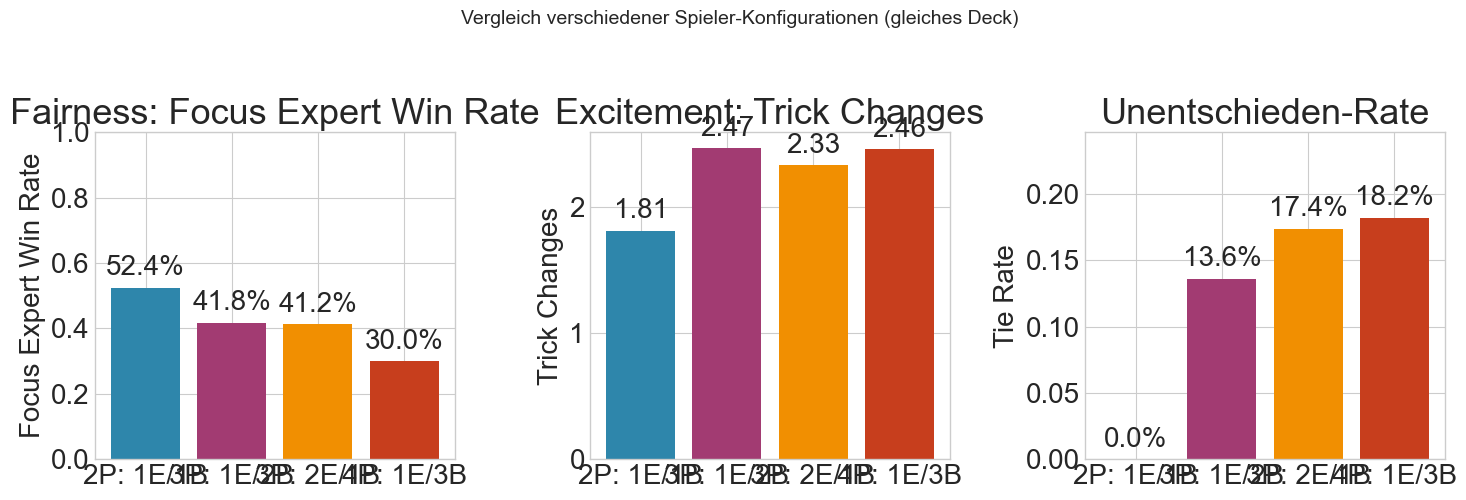


-> Plot gespeichert: plots/multiplayer/configuration_comparison.png


In [17]:
comparison_df = pd.DataFrame(comparison_results)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']

ax1 = axes[0]
bars1 = ax1.bar(comparison_df['Config'], comparison_df['Focus Expert Win Rate'], color=colors[:len(comparison_df)])
ax1.set_ylabel('Focus Expert Win Rate')
ax1.set_title('Fairness: Focus Expert Win Rate')
ax1.set_ylim(0, 1)
for bar, val in zip(bars1, comparison_df['Focus Expert Win Rate']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, f'{val:.1%}', ha='center', va='bottom')

ax2 = axes[1]
bars2 = ax2.bar(comparison_df['Config'], comparison_df['Trick Changes'], color=colors[:len(comparison_df)])
ax2.set_ylabel('Trick Changes')
ax2.set_title('Excitement: Trick Changes')
for bar, val in zip(bars2, comparison_df['Trick Changes']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05, f'{val:.2f}', ha='center', va='bottom')

ax3 = axes[2]
bars3 = ax3.bar(comparison_df['Config'], comparison_df['Tie Rate'], color=colors[:len(comparison_df)])
ax3.set_ylabel('Tie Rate')
ax3.set_title('Unentschieden-Rate')
ax3.set_ylim(0, max(comparison_df['Tie Rate']) * 1.3 + 0.01)
for bar, val in zip(bars3, comparison_df['Tie Rate']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.1%}', ha='center', va='bottom')

plt.suptitle('Vergleich verschiedener Spieler-Konfigurationen (gleiches Deck)', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'configuration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'\n-> Plot gespeichert: {PLOTS_DIR / "configuration_comparison.png"}')

---

## 7. Zusammenfassung

Die Multiplayer-Simulation ist bereit für die Optimierung im nächsten Notebook (`02_optimization.ipynb`).

### Wichtige Erkenntnisse

1. **Mehr Spieler → Mehr Komplexität:** Die Win-Rate des Experten sinkt mit mehr Gegnern.
2. **Trick Changes skalieren:** Mehr Spieler führen tendenziell zu mehr Führungswechseln.
3. **Ties werden häufiger:** Bei mehr Spielern steigt die Wahrscheinlichkeit für Unentschieden.

In [18]:
print('\n' + '=' * 60)
print('SETUP ABGESCHLOSSEN')
print('=' * 60)
print(f'\nAktuelle Konfiguration für Optimierung:')
print(f'  Spieler:          {NUM_PLAYERS} ({NUM_EXPERTS} Experten, {NUM_BEGINNERS} Anfänger)')
print(f'  Strategien:       {PLAYER_STRATEGIES}')
print(f'  Karten:           {K}')
print(f'  Kategorien:       {L}')
print(f'  Entscheidungsvar: {K * L}')
print(f'\n-> Weiter mit: 02_optimization.ipynb')


SETUP ABGESCHLOSSEN

Aktuelle Konfiguration für Optimierung:
  Spieler:          3 (1 Experten, 2 Anfänger)
  Strategien:       ['p4', 'p0', 'p0']
  Karten:           24
  Kategorien:       4
  Entscheidungsvar: 96

-> Weiter mit: 02_optimization.ipynb
